# BetaGDD — Multi-species comparison (PEP725 fruit trees)

Fits three model variants on 7 PEP725 fruit tree species and compares performance
and identifiability:

1. **Per-species global** — one `GlobalBetaGDDModel` per species (independent fits).
2. **Pooled one-hot** — `OneHotSpeciesBetaGDDModel` trained on all species jointly;
   species identity drives α/β.
3. **Pooled phylogenetic** — `PhylogeneticBetaGDDModel`; MDS coordinates of
   evolutionary distance drive α/β.

Key questions:
- Does species context improve predictive performance over independent fits?
- Do the contextual models learn meaningfully different α/β per species, or do they
  collapse to a global solution?

## Config

In [1]:
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pysephone.constants import KEY_DATA_SOURCE, KEY_SPECIES_ID
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.observations import Observations
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.dataset.util.phylogeny import PhylogenyFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.beta_gdd import (
    GlobalBetaGDDModel,
    OneHotSpeciesBetaGDDModel,
    PhylogeneticBetaGDDModel,
)

DATASETS_CONFIG = {
    'Apple':   dict(key='PEP725_Apple',   obs_key='BBCH_60', name='Malus x domestica'),
    'Pear':    dict(key='PEP725_Pear',    obs_key='BBCH_60', name='Pyrus communis'),
    'Peach':   dict(key='PEP725_Peach',   obs_key='BBCH_60', name='Prunus persica'),
    'Almond':  dict(key='PEP725_Almond',  obs_key='BBCH_60', name='Prunus amygdalis'),
    'Cherry':  dict(key='PEP725_Cherry',  obs_key='BBCH_60', name='Prunus avium'),
    'Apricot': dict(key='PEP725_Apricot', obs_key='BBCH_60', name='Prunus armeniaca'),
    'Plum':    dict(key='PEP725_Plum',    obs_key='BBCH_60', name='Prunus domestica'),
}

CUTOFF         = 2010
PHYLO_K_EMBED  = len(DATASETS_CONFIG)
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'

# GlobalBetaGDDModel — includes alpha/beta init and learn_bounds
GLOBAL_MODEL_KWARGS = dict(
    t_low            = 1.4,
    t_high           = 15.9,
    learn_bounds     = False,
    alpha_init       = 2.0,
    beta_init        = 2.0,
    learn_alpha_beta = True,
    learn_t_base     = False,
    t_base_init      = 5.0,
    learn_thresholds = True,
)

# CtxBetaGDDModel subclasses — no learn_bounds, alpha_init, beta_init, learn_alpha_beta
# (bounds are always fixed; MLP initialises α/β internally)
CTX_MODEL_KWARGS = dict(
    t_low            = 1.4,
    t_high           = 15.9,
    learn_t_base     = False,
    t_base_init      = 5.0,
    learn_thresholds = True,
)

FIT_KWARGS = dict(
    num_epochs               = 1000,
    batch_size               = 512,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-4,
    device                   = DEVICE,
    verbose                  = False,
)

print('Device:', DEVICE)

Device: cuda


## 1. Load data

In [2]:
cal = Calendar(default_start='10-01', default_length=365)

per_species_trn: dict[str, Dataset] = {}
per_species_tst: dict[str, Dataset] = {}

def target_fn_for(obs_key):
    return lambda s: s['observations'][obs_key]

target_fn = target_fn_for('BBCH_60')

for label, cfg in DATASETS_CONFIG.items():
    cache = FeatureCache.load(FeatureCache.default_path(cfg['key'], ['temperature_2m_mean']))
    ds    = Dataset.load(cfg['key'], calendar=cal, feature_providers=[cache])
    ys_trn = [y for y in ds.years if y <  CUTOFF]
    ys_tst = [y for y in ds.years if y >= CUTOFF]
    per_species_trn[label] = ds.select_years(ys_trn)
    per_species_tst[label] = ds.select_years(ys_tst)
    print(f'{label:8s}  train={len(per_species_trn[label]):5d}  test={len(per_species_tst[label]):4d}  '
          f'years {min(ys_trn)}–{max(ys_tst)}')

# Pooled datasets
pool_cache = FeatureCache.load(FeatureCache.default_path('PEP725_fruit_trees', ['temperature_2m_mean']))

pooled_obs_trn = reduce(Observations.merge, [per_species_trn[l]._obs for l in DATASETS_CONFIG])
pooled_obs_tst = reduce(Observations.merge, [per_species_tst[l]._obs for l in DATASETS_CONFIG])

ds_pool_trn = Dataset(pooled_obs_trn, calendar=cal, feature_providers=[pool_cache])
ds_pool_tst = Dataset(pooled_obs_tst, calendar=cal, feature_providers=[pool_cache])

print(f'\nPooled  train={len(ds_pool_trn)}  test={len(ds_pool_tst)}')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 46752.65it/s]


Apple     train= 5223  test=1538  years 1986–2015


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 31378.83it/s]


Pear      train= 1929  test=1355  years 1986–2015


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 31781.95it/s]


...

Cherry    train= 5866  test=1699  years 1986–2016


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 45197.80it/s]


Apricot   train=   20  test= 170  years 1986–2016


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 45061.06it/s]


Plum      train= 2703  test= 401  years 1986–2016

Pooled  train=16836  test=5214


## 2. Per-species GlobalBetaGDDModel

In [3]:
global_models: dict[str, GlobalBetaGDDModel] = {}

for label in DATASETS_CONFIG:
    print(f'Fitting {label}...', end=' ', flush=True)
    m, _ = GlobalBetaGDDModel.fit(
        target_fn    = target_fn,
        dataset      = per_species_trn[label],
        model_kwargs = GLOBAL_MODEL_KWARGS,
        **FIT_KWARGS,
    )
    global_models[label] = m
    print(f'α={m.alpha.item():.3f}  β={m.beta.item():.3f}')

Fitting Apple... α=1.395  β=3.471
Fitting Pear... α=1.719  β=2.560
Fitting Peach... α=1.896  β=2.111
Fitting Almond... α=1.852  β=1.870
Fitting Cherry... α=1.366  β=4.436
Fitting Apricot... α=1.838  β=2.169
Fitting Plum... α=1.804  β=3.036


## 3. Pooled contextual models

In [4]:
# Phylogeny — MDS embedding from evolutionary distance matrix
phylo = PhylogenyFeatures(k_embed=PHYLO_K_EMBED, output=['mds']).fit(pooled_obs_trn)
species_keys = list(phylo.species_keys)
print(f'Species keys ({len(species_keys)}):  {species_keys}')
print(f'MDS coords shape: {phylo.mds_coords.shape}')

/home/ron/Repositories/pysephone/src/pysephone/dataset/util/phylogeny.py:184: UserWarning: PhylogenyFeatures: approximate match for 'Prunus amygdalis' → 'Prunus amygdalus'
  warnings.warn(


Species keys (7):  [('pep725', 202), ('pep725', 205), ('pep725', 220), ('pep725', 222), ('pep725', 225), ('pep725', 227), ('pep725', 782)]
MDS coords shape: (7, 6)


In [5]:
print('Fitting one-hot species model...')
model_onehot, _ = OneHotSpeciesBetaGDDModel.fit(
    target_fn    = target_fn,
    dataset      = ds_pool_trn,
    model_kwargs = dict(CTX_MODEL_KWARGS, species_keys=species_keys, ctx_hidden=16),
    **FIT_KWARGS,
)
print('Done.')

print('Fitting phylogenetic model...')
model_phylo = PhylogeneticBetaGDDModel.from_phylogeny_features(
    phylo, ctx_hidden=16, **CTX_MODEL_KWARGS,
)
model_phylo, _ = PhylogeneticBetaGDDModel.fit(
    target_fn    = target_fn,
    dataset      = ds_pool_trn,
    model        = model_phylo,
    **FIT_KWARGS,
)
print('Done.')

Fitting one-hot species model...
Done.
Fitting phylogenetic model...
Done.


## 4. Performance comparison

In [6]:
def eval_metrics(model, ds_trn, ds_tst, t_fn, name):
    res = SingleTargetRegression.run(
        model=model, dataset_train=ds_trn, dataset_test=ds_tst,
        target_fn=t_fn, run_name=name,
    )
    m = res.compute_metrics()
    return {split: m[split] for split in ('train', 'test')}

rows = []

for label in DATASETS_CONFIG:
    for split, metrics in eval_metrics(
        global_models[label],
        per_species_trn[label], per_species_tst[label],
        target_fn, f'global_{label}',
    ).items():
        rows.append(dict(model='global', species=label, split=split, **metrics))

for model_name, model, ds_trn, ds_tst in [
    ('onehot', model_onehot, ds_pool_trn, ds_pool_tst),
    ('phylo',  model_phylo,  ds_pool_trn, ds_pool_tst),
]:
    # Evaluate per-species by slicing the pooled test set
    for label in DATASETS_CONFIG:
        sp_trn = per_species_trn[label]
        sp_tst = per_species_tst[label]
        for split, metrics in eval_metrics(
            model, sp_trn, sp_tst, target_fn, f'{model_name}_{label}'
        ).items():
            rows.append(dict(model=model_name, species=label, split=split, **metrics))

df_perf = pd.DataFrame(rows)

# MAE table (test split)
pivot_mae = df_perf[df_perf.split == 'test'].pivot(
    index='species', columns='model', values='mae'
).reindex(index=list(DATASETS_CONFIG), columns=['global', 'onehot', 'phylo']).round(2)
print('Test MAE (days) per species × model')
print(pivot_mae.to_string())
print()

# Mean across species
print('Mean test MAE:')
print(pivot_mae.mean().round(2).to_string())

Test MAE (days) per species × model
model    global  onehot  phylo
species                       
Apple      5.57    8.18   8.33
Pear       6.64    7.47   7.78
Peach     10.20    6.80   7.80
Almond    12.56   13.56  13.68
Cherry     7.21    7.25   7.18
Apricot   15.44   11.44  11.87
Plum       9.45    8.76   8.77

Mean test MAE:
model
global    9.58
onehot    9.07
phylo     9.34


In [7]:
# RMSE and R² tables
for metric in ('rmse', 'r2'):
    pivot = df_perf[df_perf.split == 'test'].pivot(
        index='species', columns='model', values=metric
    ).reindex(index=list(DATASETS_CONFIG), columns=['global', 'onehot', 'phylo']).round(3)
    print(f'Test {metric.upper()} per species × model')
    print(pivot.to_string())
    print()

Test RMSE per species × model
model    global  onehot   phylo
species                        
Apple     7.884  11.070  11.342
Pear      8.801   9.962  10.433
Peach    15.382   9.487  10.020
Almond   16.095  17.028  17.030
Cherry   11.389  10.314  10.231
Apricot  22.274  17.172  17.798
Plum     14.530  12.930  12.895

Test R2 per species × model
model    global  onehot  phylo
species                       
Apple     0.128  -0.718 -0.804
Pear      0.146  -0.094 -0.200
Peach    -0.658   0.369  0.296
Almond   -0.391  -0.557 -0.557
Cherry   -0.595  -0.308 -0.287
Apricot  -1.887  -0.716 -0.843
Plum     -0.867  -0.478 -0.470



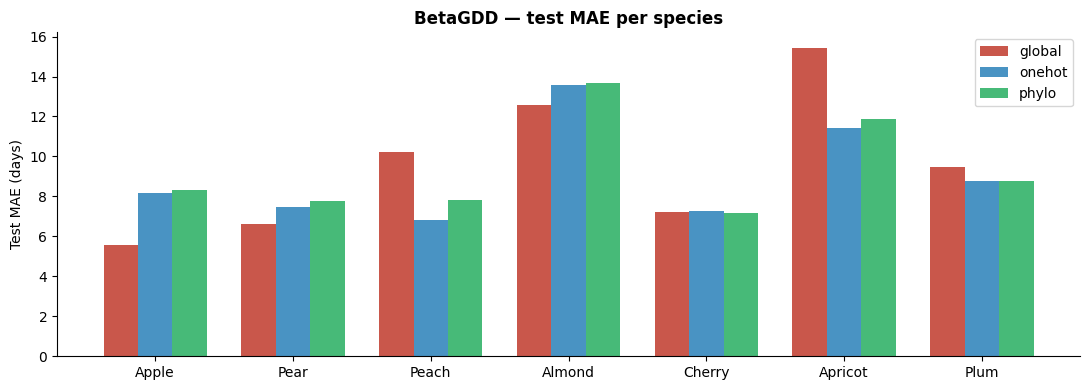

In [8]:
# Bar plot: test MAE per species, grouped by model
fig, ax = plt.subplots(figsize=(11, 4))
species_list = list(DATASETS_CONFIG)
x = np.arange(len(species_list))
w = 0.25
colors = {'global': '#c0392b', 'onehot': '#2980b9', 'phylo': '#27ae60'}

for i, model_name in enumerate(['global', 'onehot', 'phylo']):
    vals = [pivot_mae.loc[s, model_name] for s in species_list]
    ax.bar(x + (i - 1) * w, vals, w, label=model_name, color=colors[model_name], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(species_list)
ax.set_ylabel('Test MAE (days)')
ax.set_title('BetaGDD — test MAE per species', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Identifiability: learned α/β per species

Compare the α and β each model assigns to each species.
- **Global**: learned scalar per independent fit.
- **One-hot / phylo**: the MLP output for each species' context vector.

If contextual models assign meaningfully different α/β per species (high variance across
species), the context is being used.  If all species get similar values, the MLP collapsed
to a global solution despite having species-specific context.

In [9]:
def get_species_ab(ctx_model, species_keys_list):
    """Get predicted α/β per species from a contextual model.
    Passes a one-sample-per-species batch with dummy temperature data.
    """
    ctx_model.eval()
    result = {}
    device = next(ctx_model.parameters()).device
    with torch.no_grad():
        for src, sid in species_keys_list:
            xs = {
                KEY_DATA_SOURCE: [src],
                KEY_SPECIES_ID:  [sid],
            }
            cf = ctx_model.get_cf_parameters(xs)
            result[(src, sid)] = {
                'alpha': cf['alpha'].item(),
                'beta':  cf['beta'].item(),
            }
    return result


# Per-species α/β from global models
global_ab = {
    label: {'alpha': m.alpha.item(), 'beta': m.beta.item()}
    for label, m in global_models.items()
}

# Per-species α/β from contextual models
onehot_ab = get_species_ab(model_onehot, species_keys)
phylo_ab  = get_species_ab(model_phylo,  species_keys)

# Map (src, species_id) back to label using the pooled observations
sid_to_label = {
    tuple(k): label
    for label in DATASETS_CONFIG
    for k in pooled_obs_trn.species_names
    if pooled_obs_trn.species_names[k] == DATASETS_CONFIG[label]['name']
}
# Fallback: map by position if name lookup fails
if not sid_to_label:
    sid_to_label = {k: list(DATASETS_CONFIG.keys())[i] for i, k in enumerate(species_keys)}

rows_ab = []
for label, ab in global_ab.items():
    rows_ab.append(dict(model='global', species=label, **ab))
for (src, sid), ab in onehot_ab.items():
    label = sid_to_label.get((src, sid), f'{src}/{sid}')
    rows_ab.append(dict(model='onehot', species=label, **ab))
for (src, sid), ab in phylo_ab.items():
    label = sid_to_label.get((src, sid), f'{src}/{sid}')
    rows_ab.append(dict(model='phylo', species=label, **ab))

df_ab = pd.DataFrame(rows_ab)
print(df_ab.pivot(index='species', columns='model', values='alpha').round(3).to_string())
print()
print(df_ab.pivot(index='species', columns='model', values='beta').round(3).to_string())

model    global  onehot  phylo
species                       
Almond    1.852   1.002  1.004
Apple     1.395   1.000  1.000
Apricot   1.838   1.003  1.000
Cherry    1.366   1.000  1.000
Peach     1.896   1.003  1.000
Pear      1.719   1.000  1.000
Plum      1.804   1.000  1.000

model    global  onehot   phylo
species                        
Almond    1.870   4.222   4.046
Apple     3.471  16.326  15.700
Apricot   2.169   7.732   7.528
Cherry    4.436  10.585  10.020
Peach     2.111   9.657   8.439
Pear      2.560  13.261  13.012
Plum      3.036  13.261  11.250


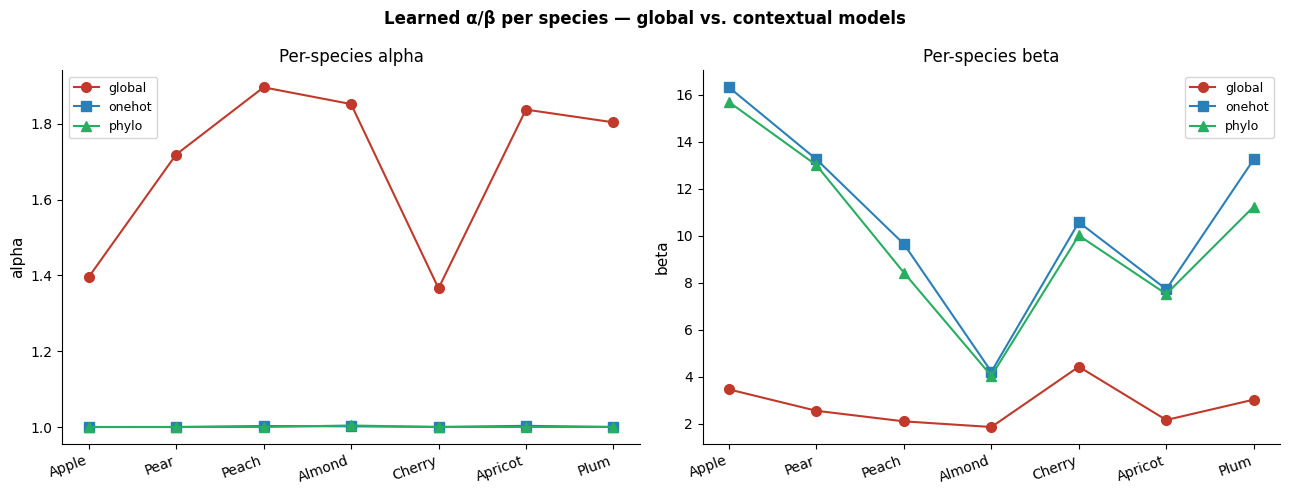

std(α) across species — higher = context is being used:
  global    std(α)=0.2057  std(β)=0.8433
  onehot    std(α)=0.0012  std(β)=3.7154
  phylo     std(α)=0.0014  std(β)=3.5279


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Learned α/β per species — global vs. contextual models',
             fontsize=12, fontweight='bold')

model_colors = {'global': '#c0392b', 'onehot': '#2980b9', 'phylo': '#27ae60'}
model_markers = {'global': 'o', 'onehot': 's', 'phylo': '^'}
x = np.arange(len(DATASETS_CONFIG))
species_list = list(DATASETS_CONFIG)

for ax, param in zip(axes, ['alpha', 'beta']):
    for model_name in ['global', 'onehot', 'phylo']:
        vals = [
            df_ab[(df_ab.model == model_name) & (df_ab.species == s)][param].values[0]
            if len(df_ab[(df_ab.model == model_name) & (df_ab.species == s)]) > 0
            else np.nan
            for s in species_list
        ]
        ax.plot(x, vals, marker=model_markers[model_name], color=model_colors[model_name],
                lw=1.5, ms=7, label=model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(species_list, rotation=20, ha='right')
    ax.set_ylabel(param, fontsize=11)
    ax.set_title(f'Per-species {param}')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Variance summary
print('std(α) across species — higher = context is being used:')
for model_name in ['global', 'onehot', 'phylo']:
    vals = df_ab[df_ab.model == model_name]['alpha'].values
    print(f'  {model_name:8s}  std(α)={vals.std():.4f}  std(β)={df_ab[df_ab.model == model_name]["beta"].values.std():.4f}')